# OpenCV Document Validator — Results Explorer

**Two modes:**
1. **Load existing results** — reads `eval_results/batch_results.csv`, re-runs OpenCV to enrich with raw feature scores
2. **Re-run on folder** — point `SCAN_FOLDER` to any directory, run OpenCV fresh, get full score dataframe

Change thresholds in Section 1 and re-run any section independently.

## 1. Config — thresholds

In [8]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd() / "src"))

import dataclasses
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2
from IPython.display import display
from sklearn.metrics import classification_report, confusion_matrix, f1_score

from document_validation import ValidationConfig, validate_document_file_ensemble
from document_validation.validator import validate_document_image, _load_image, _render_pdf_pages
from document_validation.ground_truth import FOLDER_TO_LABEL

# ── Thresholds — edit here and re-run any section ────────────────────────────
CONFIG = ValidationConfig(
    blur_laplacian_threshold   = 2000.0,
    blur_tenengrad_threshold   = 65.0,
    min_readability_contrast   = 65.0,
    max_low_readability_gray_std = 65.0,
    min_document_confidence    = 0.75,
    min_reject_confidence      = 0.50,
    pdf_dpi                    = 200,
)

# Show thresholds as a table
threshold_fields = [
    'blur_laplacian_threshold', 'blur_tenengrad_threshold',
    'min_readability_contrast', 'max_low_readability_gray_std',
    'min_document_confidence', 'min_reject_confidence', 'pdf_dpi'
]
cfg_dict = dataclasses.asdict(CONFIG)
display(pd.DataFrame(
    [(k, cfg_dict[k]) for k in threshold_fields],
    columns=['threshold', 'value']
).set_index('threshold'))

PROJECT_ROOT = Path.cwd()
OUT_DIR = PROJECT_ROOT / 'eval_results'
OUT_DIR.mkdir(exist_ok=True)
EXTENSIONS = {'.jpg', '.jpeg', '.png', '.webp', '.bmp', '.pdf'}
LABELS = ['accepted', 'blur', 'cut', 'not_document']
TIE_BREAK = ('not_document', 'blur', 'not_clear', 'cut', 'accepted')

,value
threshold,
blur_laplacian_threshold,2000.00
blur_tenengrad_threshold,65.00
min_readability_contrast,65.00
max_low_readability_gray_std,65.00
min_document_confidence,0.75
min_reject_confidence,0.50
pdf_dpi,200.00


## 2. Helpers — score extraction

In [9]:
def _label_from_issues(issues):
    normalised = ['blur' if i == 'not_clear' else i for i in issues]
    if not normalised:
        return 'accepted'
    for label in TIE_BREAK:
        if label in normalised:
            return label
    return normalised[0]


def score_page(page_bgr, config=CONFIG):
    """Run OpenCV on one BGR image, return flat score dict."""
    r = validate_document_image(page_bgr, config=config)
    return {
        # blur
        'laplacian_variance'  : round(r.blur.laplacian_variance, 2),
        'tenengrad'           : round(r.blur.tenengrad, 2),
        'readability_contrast': round(r.blur.readability_contrast, 2),
        'grayscale_std'       : round(r.blur.grayscale_std, 2),
        'blur_confidence'     : round(r.blur.confidence, 3),
        # document
        'doc_confidence'      : round(r.document.confidence, 3),
        'page_area_ratio'     : round(r.document.page_area_ratio, 3),
        'ink_ratio'           : round(r.document.ink_ratio, 3),
        'edge_density'        : round(r.document.edge_density, 3),
        # cut
        'cut_confidence'      : round(r.cut.confidence, 3),
        # clear
        'clear_confidence'    : round(r.clear.confidence, 3),
        # thresholds used
        'thresh_laplacian'    : config.blur_laplacian_threshold,
        'thresh_tenengrad'    : config.blur_tenengrad_threshold,
        'thresh_min_doc_conf' : config.min_document_confidence,
        'thresh_min_reject'   : config.min_reject_confidence,
        # prediction
        'raw_issues'          : ', '.join(r.issues) if r.issues else '',
        'predicted_label'     : _label_from_issues(r.issues),
    }


def score_file(file_path, config=CONFIG):
    """Score the first page of a file, return score dict."""
    fp = Path(file_path)
    try:
        if fp.suffix.lower() == '.pdf':
            pages = list(_render_pdf_pages(fp, config))
            page = pages[0] if pages else None
        else:
            page = _load_image(fp)
        if page is None:
            raise ValueError('empty page')
        scores = score_page(page, config)
    except Exception as exc:
        scores = {'predicted_label': 'error', 'raw_issues': str(exc)}
    scores['file_path'] = str(fp)
    scores['filename']  = fp.name
    return scores


print('Helpers loaded.')

Helpers loaded.


## 3. Load existing results

Reads `eval_results/batch_results.csv` (319 files from the last full eval run),
then re-scores each file with the current `CONFIG` to attach raw feature columns.

In [10]:
BATCH_CSV = OUT_DIR / 'batch_results.csv'

if not BATCH_CSV.exists():
    print(f'batch_results.csv not found at {BATCH_CSV}. Run run_eval.py first.')
else:
    base_df = pd.read_csv(BATCH_CSV)
    base_df['file_path'] = base_df['file_path'].apply(Path)
    print(f'Loaded {len(base_df)} rows from {BATCH_CSV}')
    display(base_df['expected_label'].value_counts().rename('count').to_frame())

Loaded 319 rows from /Users/mipl/Documents/ML_pipeline/Document_validation/eval_results/batch_results.csv


,count
expected_label,
blur,140
not_document,72
accepted,71
cut,36


In [11]:
# Re-score with current thresholds to get raw feature columns
# This takes ~5-8 minutes (same as run_eval.py)
# Set RESCORE = False to skip and use only what's in the CSV
RESCORE = True

if RESCORE and BATCH_CSV.exists():
    score_rows = []
    n = len(base_df)
    for i, (_, row) in enumerate(base_df.iterrows()):
        s = score_file(row['file_path'], CONFIG)
        s['expected_label'] = row['expected_label']
        s['doc_type']       = row.get('doc_type', '')
        s['state']          = row.get('state', '')
        score_rows.append(s)
        if (i + 1) % 50 == 0 or i == n - 1:
            print(f'  {i+1}/{n}', end='\r')

    results_df = pd.DataFrame(score_rows)
    results_df.to_csv(OUT_DIR / 'batch_results_scored.csv', index=False)
    print(f'\nRe-scored {len(results_df)} files → eval_results/batch_results_scored.csv')
else:
    # Load from pre-scored CSV if it exists
    scored_csv = OUT_DIR / 'batch_results_scored.csv'
    if scored_csv.exists():
        results_df = pd.read_csv(scored_csv)
        print(f'Loaded pre-scored results: {len(results_df)} rows')
    else:
        results_df = base_df.copy()
        print('Using base CSV (no feature scores — set RESCORE=True to enrich)')

  319/319
Re-scored 319 files → eval_results/batch_results_scored.csv


In [12]:
# Full results dataframe — sort by expected label then state
col_order = [
    'filename', 'doc_type', 'state', 'expected_label', 'predicted_label', 'raw_issues',
    'laplacian_variance', 'tenengrad', 'readability_contrast', 'grayscale_std',
    'blur_confidence', 'doc_confidence', 'cut_confidence', 'clear_confidence',
    'ink_ratio', 'edge_density', 'page_area_ratio',
    'thresh_laplacian', 'thresh_tenengrad', 'thresh_min_doc_conf', 'thresh_min_reject',
    'file_path',
]
show_cols = [c for c in col_order if c in results_df.columns]
display_df = results_df[show_cols].sort_values(['expected_label', 'state'])

def highlight_wrong(row):
    wrong = row.get('expected_label') != row.get('predicted_label')
    return ['background-color: #ffeaea' if wrong else '' for _ in row]

display(
    display_df.style
    .apply(highlight_wrong, axis=1)
    .format(precision=3)
)

,filename,doc_type,state,expected_label,predicted_label,raw_issues,laplacian_variance,tenengrad,readability_contrast,grayscale_std,blur_confidence,doc_confidence,cut_confidence,clear_confidence,ink_ratio,edge_density,page_area_ratio,thresh_laplacian,thresh_tenengrad,thresh_min_doc_conf,thresh_min_reject,file_path
8,19136_farmer_19136_cf.pdf,ConcentForm,Andhra_Pradesh,accepted,blur,"not_clear, cut",2269.210,110.460,49.500,31.870,0.000,0.927,1.000,0.490,0.107,0.085,0.916,2000.000,65.000,0.750,0.500,/Users/mipl/Documents/ML_pipeline/Document_validation/test_data/ConcentForm/Andhra_Pradesh/is_clear/19136_farmer_19136_cf.pdf
9,30035_farmer_30035_cf.pdf,ConcentForm,Andhra_Pradesh,accepted,cut,cut,2057.370,81.130,51.660,77.370,0.000,0.814,1.000,1.000,0.108,0.100,0.684,2000.000,65.000,0.750,0.500,/Users/mipl/Documents/ML_pipeline/Document_validation/test_data/ConcentForm/Andhra_Pradesh/is_clear/30035_farmer_30035_cf.pdf
10,70168_farmer_70168_cf.pdf,ConcentForm,Andhra_Pradesh,accepted,blur,"blur, not_clear, cut",1707.790,98.230,46.810,37.780,0.146,0.992,0.550,0.250,0.045,0.062,0.930,2000.000,65.000,0.750,0.500,/Users/mipl/Documents/ML_pipeline/Document_validation/test_data/ConcentForm/Andhra_Pradesh/is_clear/70168_farmer_70168_cf.pdf
11,71012_farmer_71012_cf.pdf,ConcentForm,Andhra_Pradesh,accepted,blur,"blur, not_clear, cut",1008.130,76.980,56.670,61.810,0.496,0.801,1.000,0.250,0.130,0.101,0.789,2000.000,65.000,0.750,0.500,/Users/mipl/Documents/ML_pipeline/Document_validation/test_data/ConcentForm/Andhra_Pradesh/is_clear/71012_farmer_71012_cf.pdf
28,165588_165588-94e6f5c6-c06b-462a-9fb9-efb900afd0ea.pdf,ConcentForm,GUJRAT,accepted,blur,"blur, not_clear, cut",1789.980,74.350,78.930,42.490,0.105,0.954,1.000,0.250,0.096,0.062,0.897,2000.000,65.000,0.750,0.500,/Users/mipl/Documents/ML_pipeline/Document_validation/test_data/ConcentForm/GUJRAT/is_clear/165588_165588-94e6f5c6-c06b-462a-9fb9-efb900afd0ea.pdf
29,165641_165641-18b85ebc-818f-45ab-a0d1-3315e7ce0645.pdf,ConcentForm,GUJRAT,accepted,cut,cut,6025.980,123.610,90.450,29.960,0.000,0.976,0.550,1.000,0.070,0.061,0.993,2000.000,65.000,0.750,0.500,/Users/mipl/Documents/ML_pipeline/Document_validation/test_data/ConcentForm/GUJRAT/is_clear/165641_165641-18b85ebc-818f-45ab-a0d1-3315e7ce0645.pdf
30,167196_167196-010ba21e-dd91-4888-bb2b-574ca119515f.pdf,ConcentForm,GUJRAT,accepted,blur,"blur, not_clear",955.190,77.910,62.580,22.400,0.522,0.965,0.000,0.250,0.081,0.064,0.998,2000.000,65.000,0.750,0.500,/Users/mipl/Documents/ML_pipeline/Document_validation/test_data/ConcentForm/GUJRAT/is_clear/167196_167196-010ba21e-dd91-4888-bb2b-574ca119515f.pdf
31,167235_167235-34496b7d-752e-4a35-bcaf-eb022a00c05e.pdf,ConcentForm,GUJRAT,accepted,blur,"blur, not_clear",913.960,76.200,56.510,20.140,0.543,0.976,0.000,0.250,0.072,0.059,0.996,2000.000,65.000,0.750,0.500,/Users/mipl/Documents/ML_pipeline/Document_validation/test_data/ConcentForm/GUJRAT/is_clear/167235_167235-34496b7d-752e-4a35-bcaf-eb022a00c05e.pdf
185,165568_162612-d3ce14da-7e15-4fd7-8025-a6b83727bc09.pdf,Landrecord,GUJRAT,accepted,blur,"blur, not_clear, cut",2256.090,57.580,55.610,36.940,0.114,0.871,1.000,0.250,0.059,0.042,0.922,2000.000,65.000,0.750,0.500,/Users/mipl/Documents/ML_pipeline/Document_validation/test_data/Landrecord/GUJRAT/is_clear/165568_162612-d3ce14da-7e15-4fd7-8025-a6b83727bc09.pdf
186,167153_163972-03f704b8-d11c-47a0-a9e8-e230581d5876.pdf,Landrecord,GUJRAT,accepted,blur,"blur, not_clear",1710.900,51.070,78.860,21.470,0.214,0.860,0.000,0.250,0.027,0.032,0.998,2000.000,65.000,0.750,0.500,/Users/mipl/Documents/ML_pipeline/Document_validation/test_data/Landrecord/GUJRAT/is_clear/167153_163972-03f704b8-d11c-47a0-a9e8-e230581d5876.pdf


## 4. Metrics on existing results

Files: 319  |  Accuracy: 0.455

              precision    recall  f1-score   support

    accepted       0.46      0.37      0.41        71
        blur       0.50      0.54      0.52       140
         cut       0.07      0.08      0.08        36
not_document       0.57      0.56      0.56        72

    accuracy                           0.45       319
   macro avg       0.40      0.39      0.39       319
weighted avg       0.46      0.45      0.46       319



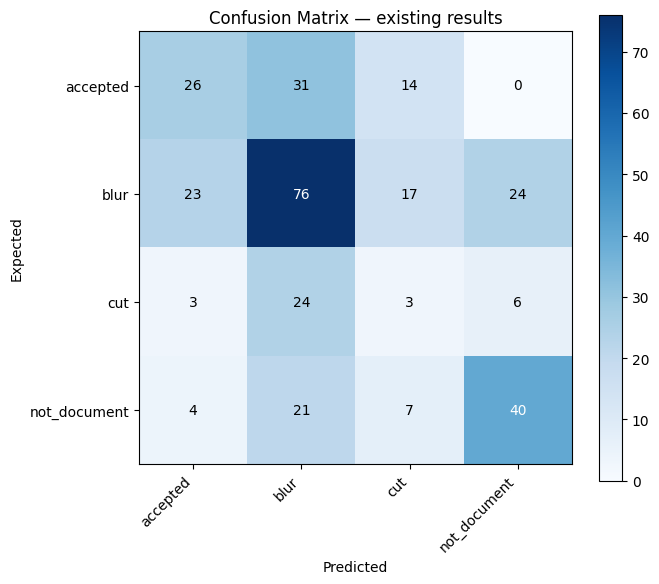

In [13]:
valid = results_df[results_df['predicted_label'] != 'error'].copy()
y_true, y_pred = valid['expected_label'], valid['predicted_label']

acc = (y_true == y_pred).mean()
print(f'Files: {len(valid)}  |  Accuracy: {acc:.3f}\n')
print(classification_report(y_true, y_pred, labels=LABELS, zero_division=0))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=LABELS)
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(len(LABELS))); ax.set_xticklabels(LABELS, rotation=45, ha='right')
ax.set_yticks(range(len(LABELS))); ax.set_yticklabels(LABELS)
ax.set_xlabel('Predicted'); ax.set_ylabel('Expected')
ax.set_title('Confusion Matrix — existing results')
for i in range(len(LABELS)):
    for j in range(len(LABELS)):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                color='white' if cm[i, j] > cm.max()/2 else 'black')
plt.colorbar(im); plt.tight_layout(); plt.show()

In [14]:
# Per-state breakdown
if 'state' in valid.columns:
    state_rows = []
    for state, grp in valid.groupby('state'):
        yt, yp = grp['expected_label'], grp['predicted_label']
        r = {'state': state, 'n': len(grp), 'accuracy': round((yt==yp).mean(), 3)}
        for cls in LABELS:
            if (yt==cls).any():
                r[f'{cls}_F1'] = round(f1_score(yt==cls, yp==cls, zero_division=0), 3)
        state_rows.append(r)
    state_df = pd.DataFrame(state_rows).set_index('state').sort_values('accuracy', ascending=False)
    display(state_df.style.background_gradient(cmap='RdYlGn', subset=['accuracy']))

,n,accuracy,accepted_F1,blur_F1,cut_F1,not_document_F1
state,,,,,,
PUNJAB,36,0.611000,0.667000,0.643000,0.000000,0.800000
HARYANA,36,0.556000,0.706000,0.516000,0.250000,0.625000
MADHYA_PRADESH,34,0.500000,0.500000,0.533000,0.000000,0.800000
TAMILNADU,16,0.500000,0.545000,0.500000,nan,0.400000
WEST_BENGAL,34,0.500000,0.364000,0.571000,0.000000,0.625000
MAHARASHATRA,35,0.429000,0.200000,0.500000,0.286000,0.556000
Karnataka,36,0.389000,0.444000,0.414000,0.000000,0.471000
TELANGANA,36,0.389000,0.250000,0.625000,0.000000,0.286000
Andhra_Pradesh,20,0.350000,0.000000,0.455000,0.000000,0.500000


## 4b. Run all test_data files

Scores every file in  using the expanded ground-truth label mapping (660 files across both doc types). Uses the same thresholds and display format as Section 3. Results saved to .

In [ ]:
from document_validation.ground_truth import load_ground_truth

TEST_DATA = PROJECT_ROOT / "test_data"
TESTDATA_CSV = OUT_DIR / "testdata_full_scored.csv"

gt_df = load_ground_truth(TEST_DATA)
print(f"Ground truth: {len(gt_df)} files")
display(gt_df["expected_label"].value_counts().rename("count").to_frame())

# Score every file
td_rows = []
n = len(gt_df)
for i, (_, row) in enumerate(gt_df.iterrows()):
    s = score_file(row["file_path"], CONFIG)
    s["expected_label"] = row["expected_label"]
    s["doc_type"]       = row["doc_type"]
    s["state"]          = row["state"]
    td_rows.append(s)
    if (i + 1) % 100 == 0 or i == n - 1:
        print(f"  {i+1}/{n}", end="")

testdata_df = pd.DataFrame(td_rows)
testdata_df.to_csv(TESTDATA_CSV, index=False)
print(f"
Scored {len(testdata_df)} files → {TESTDATA_CSV}")

# Display — same format as Section 3
show_td = [c for c in col_order if c in testdata_df.columns]
display(
    testdata_df[show_td]
    .sort_values(["expected_label", "state", "filename"])
    .style
    .apply(highlight_wrong, axis=1)
    .format(precision=3)
)

# Metrics
td_valid = testdata_df[testdata_df["predicted_label"] != "error"]
yt, yp = td_valid["expected_label"], td_valid["predicted_label"]
acc = (yt == yp).mean()
print(f"
Files: {len(td_valid)}  |  Accuracy: {acc:.3f}
")
print(classification_report(yt, yp, labels=LABELS, zero_division=0))


## 5. Re-run on a specific folder

Point `SCAN_FOLDER` to any directory.  
- If the folder follows the `doc_type/state/category/` layout, ground truth labels are inferred automatically.  
- Otherwise all files are scored with `expected_label = 'unknown'`.

Results are saved to `eval_results/folder_run_<folder_name>.csv`.

In [15]:
# ── Set the folder to scan ───────────────────────────────────────────────────
SCAN_FOLDER = Path('/Users/mipl/Documents/ML_pipeline/Document_validation/test_data/Landrecord/Andhra_Pradesh/old pathadhari/is_clear')   # ← change to any path

# ── Run ─────────────────────────────────────────────────────────────────────
assert SCAN_FOLDER.exists(), f'Folder not found: {SCAN_FOLDER}'

# Collect files and infer labels where possible
file_entries = []
for f in sorted(SCAN_FOLDER.rglob('*')):
    if not f.is_file() or f.suffix.lower() not in EXTENSIONS:
        continue
    # Try to infer label from parent folder name
    label = FOLDER_TO_LABEL.get(f.parent.name, 'unknown')
    file_entries.append({'file_path': f, 'expected_label': label})

print(f'Found {len(file_entries)} files in {SCAN_FOLDER}')
label_counts = pd.Series([e['expected_label'] for e in file_entries]).value_counts()
display(label_counts.rename('count').to_frame())

Found 4 files in /Users/mipl/Documents/ML_pipeline/Document_validation/test_data/Landrecord/Andhra_Pradesh/old pathadhari/is_clear


,count
accepted,4


In [16]:
# Score all files
folder_rows = []
n = len(file_entries)
for i, entry in enumerate(file_entries):
    s = score_file(entry['file_path'], CONFIG)
    s['expected_label'] = entry['expected_label']
    folder_rows.append(s)
    if (i + 1) % 50 == 0 or i == n - 1:
        print(f'  {i+1}/{n}', end='\r')

folder_df = pd.DataFrame(folder_rows)
out_csv = OUT_DIR / f'folder_run_{SCAN_FOLDER.name}.csv'
folder_df.to_csv(out_csv, index=False)
print(f'\nDone. {len(folder_df)} files → {out_csv}')

  4/4
Done. 4 files → /Users/mipl/Documents/ML_pipeline/Document_validation/eval_results/folder_run_is_clear.csv


In [17]:
# Display results
show_cols_f = [c for c in col_order if c in folder_df.columns]
folder_display = folder_df[show_cols_f].sort_values(['expected_label', 'filename'] if 'expected_label' in folder_df.columns else ['filename'])

display(
    folder_display.style
    .apply(highlight_wrong, axis=1)
    .format(precision=3)
)

,filename,expected_label,predicted_label,raw_issues,laplacian_variance,tenengrad,readability_contrast,grayscale_std,blur_confidence,doc_confidence,cut_confidence,clear_confidence,ink_ratio,edge_density,page_area_ratio,thresh_laplacian,thresh_tenengrad,thresh_min_doc_conf,thresh_min_reject,file_path
0,45569_ArrFarm_20213_landrec.pdf,accepted,blur,"not_clear, cut",3064.520,113.770,62.140,31.140,0.000,0.935,0.550,0.479,0.104,0.079,0.954,2000.000,65.000,0.750,0.500,/Users/mipl/Documents/ML_pipeline/Document_validation/test_data/Landrecord/Andhra_Pradesh/old pathadhari/is_clear/45569_ArrFarm_20213_landrec.pdf
1,72659_ArrFarm_33035_landrec.pdf,accepted,accepted,,2848.050,73.730,130.180,44.740,0.000,0.974,0.000,1.000,0.074,0.060,0.998,2000.000,65.000,0.750,0.500,/Users/mipl/Documents/ML_pipeline/Document_validation/test_data/Landrecord/Andhra_Pradesh/old pathadhari/is_clear/72659_ArrFarm_33035_landrec.pdf
2,73888_ArrFarm_34360_landrec.pdf,accepted,blur,"blur, not_clear",1519.290,81.240,72.590,63.910,0.240,0.865,0.450,0.250,0.067,0.077,0.766,2000.000,65.000,0.750,0.500,/Users/mipl/Documents/ML_pipeline/Document_validation/test_data/Landrecord/Andhra_Pradesh/old pathadhari/is_clear/73888_ArrFarm_34360_landrec.pdf
3,75604_ArrFarm_34748_landrec.pdf,accepted,blur,"blur, not_clear, cut",856.850,82.270,65.210,34.260,0.572,0.943,1.000,0.250,0.066,0.054,0.890,2000.000,65.000,0.750,0.500,/Users/mipl/Documents/ML_pipeline/Document_validation/test_data/Landrecord/Andhra_Pradesh/old pathadhari/is_clear/75604_ArrFarm_34748_landrec.pdf


In [ ]:
# Metrics — only if ground truth labels are available
known = folder_df[folder_df['expected_label'] != 'unknown']
if len(known) == 0:
    print('No ground-truth labels found — cannot compute metrics.')
    print('Prediction distribution:')
    display(folder_df['predicted_label'].value_counts().rename('count').to_frame())
else:
    valid_f = known[known['predicted_label'] != 'error']
    yt, yp = valid_f['expected_label'], valid_f['predicted_label']
    print(f'Files with labels: {len(valid_f)}  |  Accuracy: {(yt==yp).mean():.3f}\n')
    print(classification_report(yt, yp, labels=LABELS, zero_division=0))

    cm = confusion_matrix(yt, yp, labels=LABELS)
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks(range(len(LABELS))); ax.set_xticklabels(LABELS, rotation=45, ha='right')
    ax.set_yticks(range(len(LABELS))); ax.set_yticklabels(LABELS)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Expected')
    ax.set_title(f'Confusion Matrix — {SCAN_FOLDER.name}')
    for i in range(len(LABELS)):
        for j in range(len(LABELS)):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                    color='white' if cm[i, j] > cm.max()/2 else 'black')
    plt.colorbar(im); plt.tight_layout(); plt.show()

## 6. Feature score distributions (optional)

Shows how Laplacian variance, Tenengrad, and document confidence separate by class — useful for threshold tuning.

In [ ]:
# Use whichever df has feature scores
plot_df = results_df if 'laplacian_variance' in results_df.columns else folder_df
plot_df = plot_df[plot_df['expected_label'].isin(LABELS)].copy()

score_cols = ['laplacian_variance', 'tenengrad', 'blur_confidence', 'doc_confidence',
              'cut_confidence', 'clear_confidence']
score_cols = [c for c in score_cols if c in plot_df.columns]

COLORS = {'accepted': '#2ecc71', 'blur': '#e74c3c', 'cut': '#f39c12', 'not_document': '#9b59b6'}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, col in zip(axes, score_cols):
    for label in LABELS:
        vals = plot_df[plot_df['expected_label'] == label][col].dropna()
        if len(vals):
            ax.hist(vals, bins=30, alpha=0.5, label=label, color=COLORS.get(label, 'gray'))
    ax.set_title(col)
    ax.set_xlabel('value'); ax.set_ylabel('count')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

# Hide unused axes
for ax in axes[len(score_cols):]:
    ax.set_visible(False)

plt.suptitle('Feature score distributions by class', fontsize=13)
plt.tight_layout()
plt.show()